<a href="https://colab.research.google.com/github/AkankshaB123/ML/blob/main/Experimentation_Readout_Mobile_Games_A_BTesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Hypothesis
from scipy.stats import shapiro
import scipy.stats as stats

In [2]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.4f}'.format

# A/B Testing in Cookie Cats

The project is not only about analyzing the given data and make conclusion, but also try to simulate a real life A/B Testing project from scratch. The outline of the content:

1. Background & Problem
Introduction
2. Tools & Team Composition
3. Objective & Metrices Definition
4. Hypothesis Testing Design
5. A/A Testing
6. A/B Testing
7. Results Analysis & Interpretation
8. Launch Decision
9. Improvement Ideas & Risk Control

Given the lack of context and limited data, the project used randomization method to simulate data for some of the steps.

## 1. Background & Problem Introduction


Cookie Cats is a hugely popular mobile puzzle game developed by Tactile Entertainment. It's a classic "connect three" style puzzle game where the player must connect tiles of the same color in order to clear the board and win the level. It also features singing cats.As players progress through the game they will encounter gates that force them to wait some time before they can progress or make an in-app purchase. In this project, we will analyze the result of an A/B test where the first gate in Cookie Cats was moved from level 30 to level 40.

The aim of the testing is to evaluate whether the new Level 40 gates during the game play can effectively attract the users to play it with longer time and enhance the retention, compared with the current Level 30 gate setting. The longer time and higher retention rates will bring more revenue to the company and provide a positive impact to its long-term profitability.

The A/B testing is used to test on a subset of total user population to provide a statistical evidence for business launch decision. The data-driven approach will help the business alleviate potential risks of losing users and waste of money & time cost if the roll-out is not accepted by the users. Besides, A/B Testing will also present the product team with a outlook about the direction of the product update in the future by getting the right "feedback" from users.

## 2. Tools & Team Composition

There are many third-party A/B testing platforms provided by vendors around the world. The testing platforms normally includes diverse testing types to meet different cases. The platforms also tend to let the users make customized design such as hypothesis parameters (Type 1 & 2 Error Rates, Sides), Randomizaton strategies and techniques to automate the process of splitting the traffic in APP, Websites for controlled treatment and ETL the data to the enterprise data warehouse. The users can monitor the test outcome and decide when the change or stop the test easily in the platform interface. For big tech firms, however, they tend to design their own A/B testing platforms for more customized use case to their own and safety concerns.

The teams involved in A/B testing usually include the Product Team (get business requirements, design product features, UI and roadmaps), Project Management Team (for project timeline & agile coordination), Data Science Team (test design, set-up, data analysis and interpretation) and Data Engineering Team (support the raw and curated testing data and any related customer & metrices data). The business stakeholders are also involved in the problem statement, objective & metrices definition and make the decision on whether roll-out the new change after the test.2. Tools & Team Composition¶
There are many third-party A/B testing platforms provided by vendors around the world. The testing platforms normally includes diverse testing types to meet different cases. The platforms also tend to let the users make customized design such as hypothesis parameters (Type 1 & 2 Error Rates, Sides), Randomizaton strategies and techniques to automate the process of splitting the traffic in APP, Websites for controlled treatment and ETL the data to the enterprise data warehouse. The users can monitor the test outcome and decide when the change or stop the test easily in the platform interface. For big tech firms, however, they tend to design their own A/B testing platforms for more customized use case to their own and safety concerns.

The teams involved in A/B testing usually include the Product Team (get business requirements, design product features, UI and roadmaps), Project Management Team (for project timeline & agile coordination), Data Science Team (test design, set-up, data analysis and interpretation) and Data Engineering Team (support the raw and curated testing data and any related customer & metrices data). The business stakeholders are also involved in the problem statement, objective & metrices definition and make the decision on whether roll-out the new change after the test.

## 3. Objective & Metrices Definition

The objective of the test is to find out whether the proposed new version of the Gate (Level 40) in the game will encourage the users to play more rounds and longer time, also become more engaged in the game over days. Based on the requirement and goal, the metrices could be selected:

1. Success Metric: This is the main metric the test wish to evaluate, and it is corresponding to the ideal situation the change wish to bring to the game. The metric should be sensitive to the change, linked with the long-term benefit of the firm, measurable and can be detected within a short-term. It is also a core business question that different stakeholders need to sit together and figure out before launch the test. The Success Metric will be used to determine the sample size and many factors affect the entire experiment.

Given the rules above, we can set the success metric to Average Number of Rounds the User Played after Installing the Game. If the metric in the treatment group is clearly higher than the one in the control group, then we can conclude that the new design can effectively encourage people to play more thus enhance their engagement.

2. Driver Metrices: The metrices that contribute to the Success Metric and help complete the causual chain. They can also be the secondary metrices the business wish to enhance by the new feature/change to grow their profitability. The Retention 1-Day and Retention 7-Day are decent selection of driver metrices since they denote if the customers are trully love the new design instead of Novelty Effect.

3. Guardrail Metrices: The metrices that are closely monitored during the test to prevent the business from harming its customers with the new features introduced. The negative movement of the metrices could indicate the lowering quality of the product, dissatisfication of the customers and will suffer the business’s profit in the longer term. The typical selection of metrices is arbitary, but could be like Increase Latency, Number of Complaints from Customers or Number of Errors during each session. The product team should also design a clear threshold that if one or more metrices fall below the threshold during the test, the test needs to be stopped immediately in case of more harm to the treatment group. For simplicity, here we do not set any guardrail metrices, but it would be important to design such in a real-life controlled experiment.



## 4. Hypothesis Design

Given the problem statement, objective and metrices are clearly defined, it is time to decide the parameters for the Hypothesis Testing which is the most important part during A/B Testing.

1. Null and Alternative Hypothesis:

Null Hypothesis: There is no significant difference between the Average Number of Rounds the User Played in the Control and Treatment groups, and any difference is due to random noise.

Alternative Hypothesis (the one we are interested): There is a significant difference in the Average Number of Rounds the User Played between the two groups

The statement can also be spoken like "We believe that the new Gate Level design in the game for the existing and new users will lead to more engagement and enhanced the users' retention. We will know this is true when we see more rounds played and higher rentention rate".

2. Significance Level (False Positive Rate): 5% (rule-of-thumb);

3. Power Level (True Positive Rate = 1 - False Negative Rate): 80% (rule-of-thumb);

4. Minimum Detectable Effect (this is the min raise in the success metric that the test can be call successful, need to be defined by the business stakeholders and conduct cost & benefit analysis) : 5% absolute increase;

5. Sample Size: The size is determined by the parameters above and the estimated variance of the success metric. The variance can be derived from previous analysis project or data tables, if there is no record then an A/A Test can be utilized to derive the estimated variance.

After all required parameters are collected, a Power Analysis should be conducted to compute the Minimum Required Sample Size for each group. The relationship between the parameters with the sample size are below:

The lower the Signifiacne Level (e.g. 5% -> 1%), the larger the sample size;
The lower the Power Level (True Positive Rate), the smaller the sample size;
The larger the estimated variance, the larger the sample size;
The smaller the Minimun Detectable Effect size, the larger the sample size.

Given we already have the data, we do not need to conduct the Power Analysis here, but in real cases, an effective Power Analysis is critical to decide the trade-off between the level of required test accuracy and sampling cost (both monetary and time cost)



## 5. A/A Testing

A/A testing uses A/B testing process to test two identical versions of an experiment baseline against each other. The typical purpose of running an A/A test is to validate your experiment platform, ensure there is no selection bias and find the estimated variance for the success metric. Specifically, an A/A test is a data reliability/quality assurance procedure to evaluate the implementation of all your experiment comparisons.

Given there is no data prepared for A/A test here, I will make some simulated data using random function in pandas and briefly show the general process.

The Null Hypothesis here is there is No Signifiacent Difference between the two groups, and Alternative Hypothesis is there is difference existed. We would expect to see the Null Hypothesis is true if the A/B Testing platform is fair and there is no selection bias. The other statistical parameters stay the same with the ones in A/B testing but lower the Type 1 error rate to 1% to be more strict.

In [3]:
# 1. Create random numbers using Numpy
import numpy as np
import random

# 1: population
np.random.seed(100)
population = np.random.normal(loc = 100, scale = 3, size = 2000)

In [4]:
# 2. Split the users into two groups & assume no treatment to both (default split ratio is 50%)
G1 = []
G2 = []

for i in population:
    hash_v = random.random() # apply the hashing to determine which group to assign the unit

    if hash_v >= 0.5:
        G1.append(i)
    else:
        G2.append(i)

print(f'There are {len(G1)} samples in Group A and {len(G2)} samples in Group B')

There are 1008 samples in Group A and 992 samples in Group B


In [5]:
# 3. Statistical Tests:

# 3.1 Check for Sample Rate Mismatch (SRM): it is a common issue if the actual split ratio is different with the expected split ratio,
# thus the assumption of the test could be violated. Here performing Chi-Square for Independence:
from scipy.stats import chisquare

chisquare([len(G1),len(G2)], f_exp = [1000, 1000])

Power_divergenceResult(statistic=np.float64(0.128), pvalue=np.float64(0.7205147871362552))

From the testing result, even we saw the sample size in two groups are different (1012 VS 988), **we failed to conclude there is a significant difference between the groups from the test result**  If the P-value is very low (e.g. < 0.01), then we need to to back and fix the issue before conducting the A/B test.

In [6]:
# 3.2 Perform a single two-sample T-test on the difference between the groups
from scipy import stats

stats.ttest_ind(G1,G2)

TtestResult(statistic=np.float64(0.5492333432040849), pvalue=np.float64(0.58290670091515), df=np.float64(1998.0))

From the result, it seems there is no clear difference between the groups, which provides us more confidence in the fairness of the testing setup. Another way to intensity the evidence is to simulate the test many times and assess the distribution of P-values. In repeated A/A trials, the Null Hypothesis on a given metric should be rejected 5% of the time, and the P-value distribution should be Uniform.

In [7]:
# 3.3 Perform simulated tests using Bootstrap technique and conduct two-sample T-test on each trail, then inspect the distribution of P-values
# for all the trails
p_values = []

for a in range(10000):

    G1 = []
    G2 = []

    for i in population:
        hash_v = random.random()
        if hash_v <= 0.5:
            G1.append(i)
        else:
            G2.append(i)
    test = stats.ttest_ind(G1, G2)
    p_values.append(test.pvalue)

Text(0.5, 0, 'P-value')

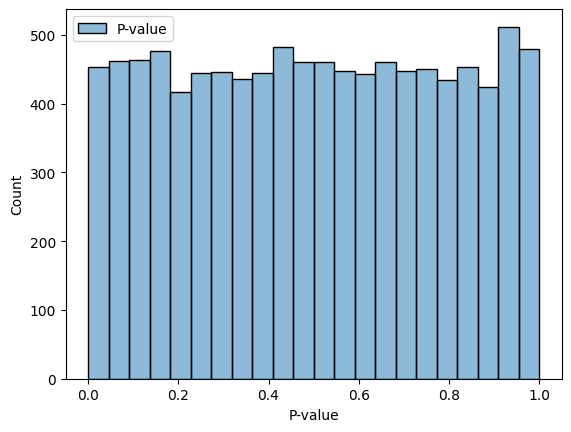

In [8]:
# Show the P-values distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame(p_values, columns = ['P-value'])
sns.histplot(data=df)
plt.xlabel("P-value")

From the histogram, it seems the P-values is in a uniform distribution. Next we gonna apply the Kolmogorov–Smirnov test to assess its uniform shape, where the null hypothesis assumes the given distribution (“p_values”) is no different from the specified distribution (“uniform”).

In [9]:
# Perform Kolmogorov Smirnov Test on the P-value distribution to assess its Uniformness:
import scipy

scipy.stats.kstest(p_values,"uniform")

KstestResult(statistic=np.float64(0.00841408225891982), pvalue=np.float64(0.47590791522013165), statistic_location=np.float64(0.9069140822589198), statistic_sign=np.int8(-1))

From the test result, we can conclude there is no evidence to indicate the P-values distribution is not Uniform, hence we can say the A/B Testing platform works as expected, with no selection bias and issues. Then, we are confident to proceed our journey to the A/B testing process.

## 6. A/B Testing¶

The testing process can be skipped here since we already got the result data. It would be critical for the Data Science team to master how to set up the platform to split the traffic while selecting the correct parameters. During the testing period, it is also important to keep monitoring the guardrail metrices and alert if one or more metrices dropped below the pre-set threshold.

The test should not be stopped until the minimum sample size for each group is captured and the success & driver metrices are collected well. The normal testing period will be within 1 month but would be adjustable based on the requirement. After collecting all the required sample size and experiment data, the experiment can be stopped and the data should be extracted properly from the platform database or the data warehouse where the ETL work happened at the backend.

## 7. Results Analysis & Interpretation¶
The steps of result interpretation are listed below:

1) Sanity Check and Preliminary Analysis

Before start testing the result, it is important to check whether the experiment data fit with the assumption and cleaned. Outliers and inconsistent values could easily violate the testing outcome and create bias to our conclusion. Firstly we need to perform an assessment on the sample size difference between the two groups.



In [12]:
data = pd.read_csv("/content/sample_data/cookie_cats.csv")
data.head(5)

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


# Sample Ratio Mismatch (SRM) Assessment

In [13]:
# 1. Sample Ratio Mismatch (SRM) Assessment
def srm_test(data, split_ratio = 0.5):

    # Check if the actual split ratio is different with the expected ratio
    if len(data[data['version'] == 'gate_40'])/len(data) != split_ratio:
        print(f"There is a difference in the sample size between the Control and Treatment group. The size in the Control Group is {len(data[data['version'] == 'gate_30'])} and the size in Treatment Group is {len(data[data['version'] == 'gate_40'])}.")

        # Conduct Chi-square test
        test = chisquare([len(data[data['version'] == 'gate_30']),len(data[data['version'] == 'gate_40'])],f_exp = [int(len(data)/2)+1,int(len(data)/2)])
    else:
        print(f"There is no difference in the sample size between the Control and Treatment groups.")

    return test

srm_test(data)

There is a difference in the sample size between the Control and Treatment group. The size in the Control Group is 44700 and the size in Treatment Group is 45489.


Power_divergenceResult(statistic=np.float64(6.919912628776534), pvalue=np.float64(0.008524114068349343))

There is a difference in the sample size between the Control and Treatment group. The size in the Control Group is 44700 and the size in Treatment Group is 45489.

Surprisingly, the test result shows since the p-value is pretty low (0.008), it could be problematic to our interpretation since we got more samples in the Treatment group than the Control group, which may contribute to baised increade in the success metric. Normally we would need to check the root cause and may need to re-run the test. However, we will skip the conclusion and proceed with the analysis.

In [14]:
# 2. Print out the summary of the data
data.drop("userid", axis = 1, inplace = True)

In [15]:
data.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
version,90189,2,gate_40,45489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sum_gamerounds,90189.0000,NaN,NaN,NaN,51.8725,195.0509,0.0000,5.0000,16.0000,51.0000,49854.0000
retention_1,90189,2,False,50036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retention_7,90189,2,False,73408,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Take a closer look at each variable

# 1) Number of Gaming rounds by Versions
data.groupby('version', as_index = False)['sum_gamerounds'].agg(['count','mean','median','std','min','max'])

,version,count,mean,median,std,min,max
0,gate_30,44700,52.4563,17.0000,256.7164,0,49854
1,gate_40,45489,51.2988,16.0000,103.2944,0,2640


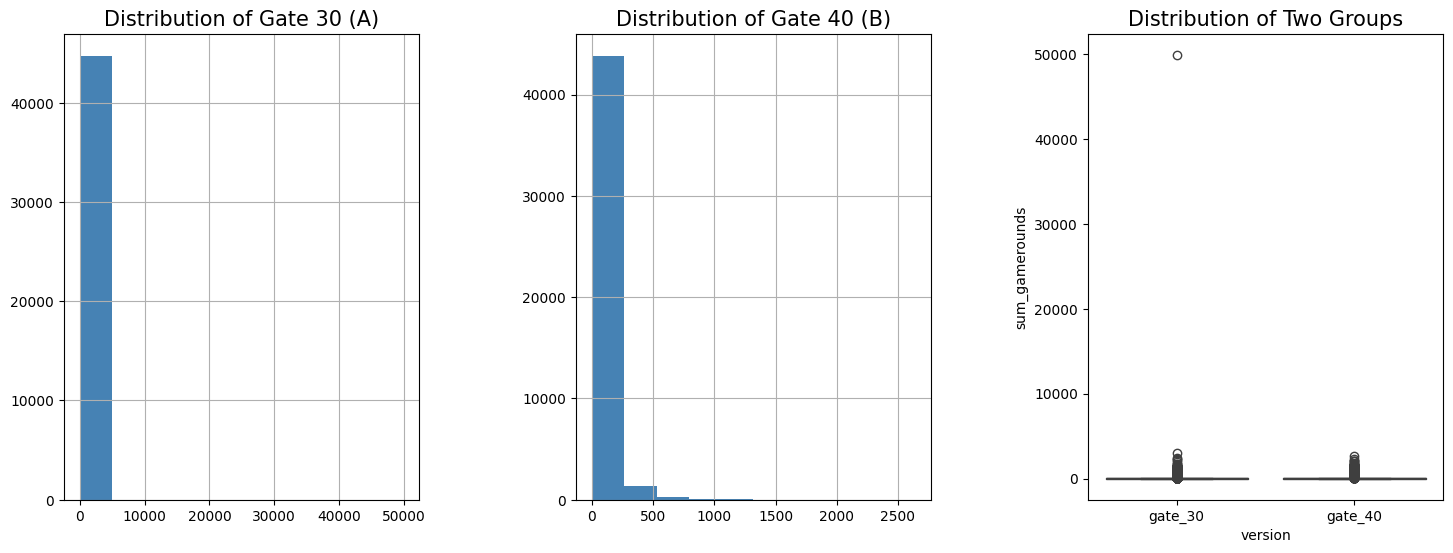

In [17]:
# Print out the distributions of Game Rounds
fig, axes = plt.subplots(1, 3, figsize = (16,7))

data[(data.version == "gate_30")].hist("sum_gamerounds", ax = axes[0], color = "steelblue")
data[(data.version == "gate_40")].hist("sum_gamerounds", ax = axes[1], color = "steelblue")
sns.boxplot(x = data.version, y = data.sum_gamerounds, ax = axes[2])

axes[0].set_title("Distribution of Gate 30 (A)", fontsize = 15)
axes[1].set_title("Distribution of Gate 40 (B)", fontsize = 15)
axes[2].set_title("Distribution of Two Groups", fontsize = 15)

plt.tight_layout(pad = 6);

We can see there are some outliers exists in the data, expecially in the Control Group (Gate 30). The outliers can be due to the errors from the testing platform or the ETL job that load the raw data into data warehouse. We need to remove the outliers before proceeding to the test

In [18]:
# It seems only the maximum value is outlier, we should remove it
data = data[data['sum_gamerounds'] < data['sum_gamerounds'].max()]

data[(data.version == "gate_30")].sort_values('sum_gamerounds').tail(5)

,version,sum_gamerounds,retention_1,retention_7
655,gate_30,1906,True,True
87007,gate_30,2156,True,True
46344,gate_30,2251,True,True
43671,gate_30,2438,True,True
7912,gate_30,2961,True,True


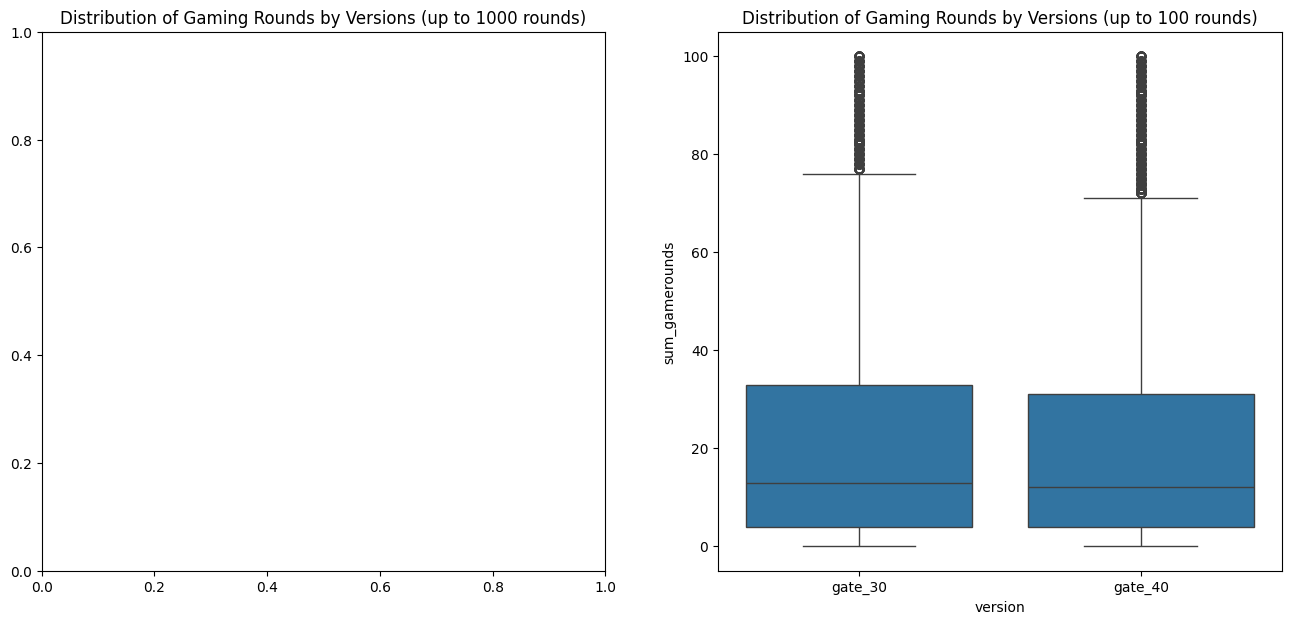

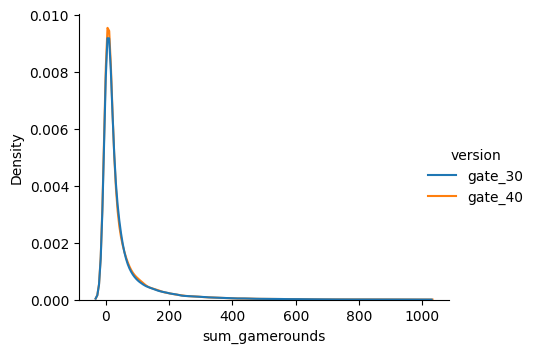

In [19]:
# Print out the distribution of Game Rounds by Players in 2 versions (Up to 1000 rounds)
fig_1, axes_1 = plt.subplots(1,2, figsize = (16,7))

sns.displot(data[data['sum_gamerounds'] <= 1000], x="sum_gamerounds", hue="version", kind="kde", ax = axes_1[0])
sns.boxplot(x = data[data['sum_gamerounds'] <= 100].version, y = data[data['sum_gamerounds'] <= 100].sum_gamerounds, ax = axes_1[1])

axes_1[0].set_title("Distribution of Gaming Rounds by Versions (up to 1000 rounds)", fontsize = 12)
axes_1[1].set_title("Distribution of Gaming Rounds by Versions (up to 100 rounds)", fontsize = 12)

plt.tight_layout(pad = 6);

## Interesting INSIGHT

From the distribution of gaming rounds by the two versions, it seems the new Gate design **did not encourage users to play more rounds than the current Gate design** As the primary metric, it indicates the design may need to be reviewed internally and improved before roll-out.

Besides, there are also plenty of users who downloaded the game but haven't played a single round. This could be due to a couple of reasons such as the game interface & mode is not appealing, the customers do not have time or their time is eaten by other games. The company should spend sometime to dig deeper into this issue and figure out which user segments showed the least interests on the game (e.g. devices, geo-location, age) so they can design specific marketing plans or change the game content to engage the users.

In [20]:
# 2) Retention Ratios:
# Check the distribution of user retention rates after 1 day and 7 days. The ideal case is that the new gate design will enhance both 1-day and 7-day retention rates

# print out the summary for the retention rates for both version groups
data_g = data.drop('sum_gamerounds', axis = 1).groupby("version").agg({'retention_1':["count", "sum"],'retention_7':['sum']}).droplevel(0, axis = 1)
data_g.columns = ['total','retention_1D_sum','retention_7D_sum']

# Make the Retention Rate for 1-Day and 7-Day
data_g['retention_1D_rate'] = data_g['retention_1D_sum']/data_g['total']
data_g['retention_7D_rate'] = data_g['retention_7D_sum']/data_g['total']

In [21]:
data_g

,total,retention_1D_sum,retention_7D_sum,retention_1D_rate,retention_7D_rate
version,,,,,
gate_30,44699,20034,8501,0.4482,0.1902
gate_40,45489,20119,8279,0.4423,0.1820


# NOVELTY EFFECT : INTERESTING INSIGHT

From the summary table above, we can find that there is a huge difference between the 1-Day and 7-Day Retention Rates. There is less than 20% users still play the game after they installed it 7 days. It seems the game had Novelty Effect on the users who was engages at first but lose interests easily after try it out.

## **Key Insight** : The 1-Day Retention Rate is not good as it is lower than 45% for both groups. We can also find both rates are slightly lower in the new version group compared with the current version, which indicates the new design did not enhance the user engagement but the other way around.

2) Result Testing

The testing phase should be the following steps:

Inspect Assumptions: Normality, Equal Variance
Perform Tests:
If the distribution is Normal and the variances are Homogeneous; apply the T-Test (parametric test)
If the distribution is Normal and the variances are not Homogeneous; apply Welch's T-Test (adaption of T-Test)
If the distribution is not Normal; apply Mann Whitney U Test directly (non-parametric test)
Result Simulation: Bootstrap
Testing result interpretation
Here an integrated function will be designed to perform the testing steps above

# 2.1) Number of Gaming Rounds¶

## Step 1 & 2:

In [25]:
from scipy.stats import shapiro
import scipy.stats as stats

# Create the A/B Testing functions
# For simplicity concern, we will set the same significance level for all the statistical tests, but in reality different test should be carefully considered regarding the Type 1 Error rates
def A_B_Testing(data, group, target, alpha = 0.05):

    # Assumption Test 1: Normality (Shapiro Normality Test)
    print("Normality Test".center(70,"*"))

    groups = data[group].unique()
    GA = data.loc[data[group] == groups[0],target]
    GB = data.loc[data[group] == groups[1],target]

    NDT_A = shapiro(GA)[1]
    NDT_B = shapiro(GB)[1]

    print(f'Normality Check: The P-value for {groups[0]} is {round(NDT_A, 5)}')
    print(f'Normality Check: The P-value for {groups[1]} is {round(NDT_B, 5)} \n')

    # Check if both groups' metrices are normally distributed
    if (NDT_A > alpha) and (NDT_B > alpha):
        print("The Normality Test is passed and no evidence of Non-normal Distribution for both \n")

        # Assumption Test 2: Equal Variance (Levene Test)
        print("Equal Variance Test ".center(70,"*"))

        levene_p = stats.levene(GA, GB)[1]
        if levene_p > alpha:
            print("The Equal Variance Test is passed and no evidence of unequal variances for both".center(20,"*"))

# Result Test: Two-Sample T-test:
            ttest_p = stats.ttest_ind(GA, GB, equal_var=True)[1]
            print(f'Two-Sample T-test: the P-value is {round(ttest_p,5)}')

        else:
            print("The Equal Variance Test is failed, the Welch's T-Test will be applied".center(20,"*"))
            # Result Test: Two-Sample Welch's T-test:
            ttest_p = stats.ttest_ind(GA, GB, equal_var=False)[1]
            print(f"Two-Sample Welch's T-test: the P-value is {round(ttest_p,5)}")

    else:
        print("The Normality Test is failed and there is evidence of Non-normal Distribution, will apply Mann Whitney U Test. \n".center(20,"*"))
        ttest_p = stats.mannwhitneyu(GA, GB)[1]
        print(f'Mann Whitney U Test: the P-value is {round(ttest_p,5)}')

    decision = "launch" if ttest_p < alpha else "not launch"
    print(f"The A/B Testing is completed, and based on the result test outcome (P-value: {round(ttest_p,5)}), we should {decision} the test based on the significance level ({alpha}).")

In [26]:
# 1. Perform Testing on the Number of Gamming Rounds
A_B_Testing(data = data,group = 'version',target = 'sum_gamerounds')

****************************Normality Test****************************
Normality Check: The P-value for gate_30 is 0.0
Normality Check: The P-value for gate_40 is 0.0 

The Normality Test is failed and there is evidence of Non-normal Distribution, will apply Mann Whitney U Test. 

Mann Whitney U Test: the P-value is 0.05089
The A/B Testing is completed, and based on the result test outcome (P-value: 0.05089), we should not launch the test based on the significance level (0.05).


From the test outcome above, we are unable to conclude that the new design did a better job of encouraging the users to play more rounds and time than the current version. Given here we set the Number of Gaming Round is our Success Metric, we can present to the product & business stakeholders. However, given our **Null Hypothesis is the population mean of gaming rounds are the same** between the two versions, and we do not know if the values in the test sample above was just a result of random sampling error, we should get more sampling cases to find the approximation of population mean and justify. Given the higher time & monetary cost of re-run the test for repeated times, it would be helpful to use simulation methods for the resampling. As long as the given sample is representative,idenpendently, identically distributed in the population, resampling from the sample data can provide us with an objective and reliable result about the population parameter.

### Step 3: Bootstrap

Doing simulations can provide us a outlook on how the metric difference will look like if we re-run the test many times and we can infer the population parameters (Number of Gaming Rounds) from the sampling result. Bootstrap is a re-sampling strategy that repeatedly samples from the original data with replacements. According to the Central Limit Theorem (CLT), the distribution of the resample means approximately normally distributed and the center is approximate to the population mean.

Text(0.5, 1.0, 'Distribution of Sample Mean Differences for Gaming Rounds of versions')

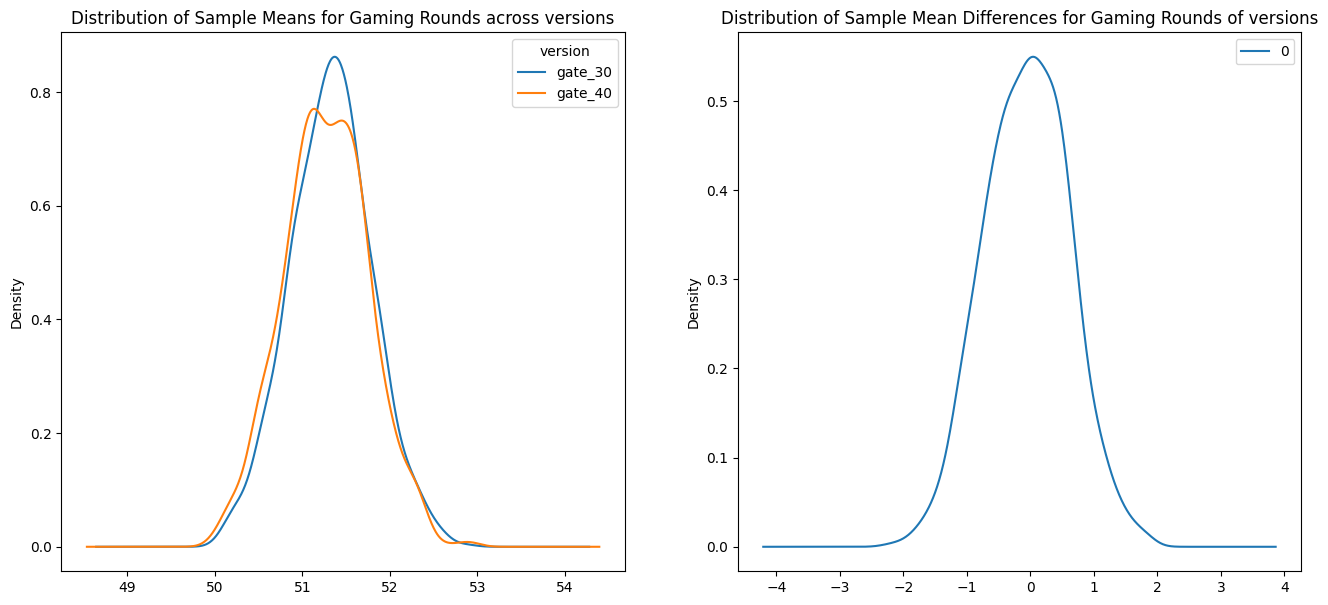

In [27]:
# 3. Result Simulation: Bootstrap
sim_mean = [] # Collect the means of the metric for all the samples
sim_diff = [] # Collect the metric difference for all the samples

for i in range(1000): # Simulate the sample for 1000 times
    sim_data = data.sample(frac = 1,replace = True)

    boot_mean = sim_data.groupby('version')['sum_gamerounds'].mean()
    boot_diff = sim_data.groupby('version')['sum_gamerounds'].mean()[1] - sim_data.groupby('version')['sum_gamerounds'].mean()[0] # level 40 gate version - level 30 gate version

    sim_mean.append(boot_mean)
    sim_diff.append(boot_diff)
# A Kernel Density Estimate plot of the bootstrap distributions
fig_2, axes_2 = plt.subplots(1,2, figsize = (16,7))

sim_mean_df = pd.DataFrame(sim_mean)
sim_diff_df = pd.DataFrame(sim_diff)

sim_mean_df.plot(kind='density', ax = axes_2[0])
sim_diff_df.plot(kind = 'density', ax = axes_2[1])
axes_2[0].set_title("Distribution of Sample Means for Gaming Rounds across versions")
axes_2[1].set_title("Distribution of Sample Mean Differences for Gaming Rounds of versions")

The bootstrap sampling result indicates that the means of gaming rounds across the two versions are similar with difference normally distributed around 0. Based on Central Limit Theorem (CLT), the population means of the 2 versions are supposed to be pretty close, which also indicates that we should not roll out the change.

# 2.2) 1-Day Retention Rates

In [28]:
# Print the aggregated table for analysis
data_g

,total,retention_1D_sum,retention_7D_sum,retention_1D_rate,retention_7D_rate
version,,,,,
gate_30,44699,20034,8501,0.4482,0.1902
gate_40,45489,20119,8279,0.4423,0.1820


In [29]:
# Perform Proportion Two-Sample Z-Test on the Retention Rate in 1-Day
# Given the Retention Rate is in the scope of Binomial Distribution, we should use the two-sample Z-test for proportions
from statsmodels.stats.proportion import proportions_ztest

prop_test_p = proportions_ztest(count = data_g['retention_1D_sum'], nobs = data_g['total'], alternative = 'two-sided',prop_var = False)[1]
print(f"The P-value of the Two-sample Z-test on 1-Day Retantion Rate is {round(prop_test_p,5)}")

The P-value of the Two-sample Z-test on 1-Day Retantion Rate is 0.07392


The P-value indicates the result is not significant compared with significance level (5%), we need to run simulation and complete our conclusion based on sampling distribution.

Text(0.5, 1.0, 'Distribution of Difference (%) of 1-Day Retention Rates of versions')

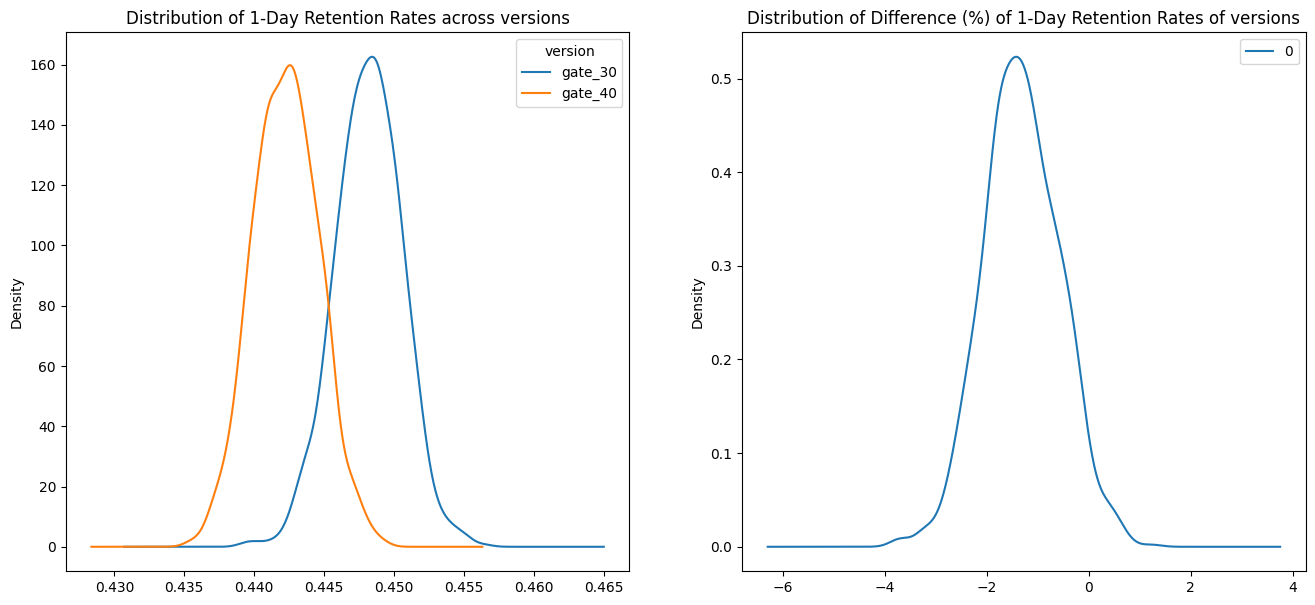

In [30]:
# Do a Bootstrap simulation to see the estimated retention rate distribution
boot_r1 = []
boot_r1_diff = []

for i in range(1000):
    boot = data.sample(frac = 1,replace = True)
    boot_mean = boot.groupby('version')['retention_1'].mean()
    boot_diff = (boot.groupby('version')['retention_1'].mean()[1] - boot.groupby('version')['retention_1'].mean()[0])/(boot.groupby('version')['retention_1'].mean()[0]) * 100

    boot_r1.append(boot_mean)
    boot_r1_diff.append(boot_diff)

# Transforming the list to a DataFrame
boot_r1 = pd.DataFrame(boot_r1)
boot_r1_diff = pd.DataFrame(boot_r1_diff)

# A Kernel Density Estimate plot of the bootstrap distributions
fig_3, axes_3 = plt.subplots(1,2, figsize = (16,7))

boot_r1.plot(kind='density', ax = axes_3[0])
boot_r1_diff.plot(kind = 'density', ax = axes_3[1])
axes_3[0].set_title("Distribution of 1-Day Retention Rates across versions", fontsize = 12)
axes_3[1].set_title("Distribution of Difference (%) of 1-Day Retention Rates of versions", fontsize = 12)

In [31]:
# Print the probability of difference lower than 0
print('Probability that 1-day Retention Rate in Level 40 is lower when the Rate at Level 30:',float((boot_r1_diff < 0).mean()))

Probability that 1-day Retention Rate in Level 40 is lower when the Rate at Level 30: 0.962


From the Bootstrap sampling process, we can find an opposite result that there is a clear difference in the 1-Day Retention Rate between the 2 versions. From the smpling distribution, there is 96% chance that the introduction of level 40 gate lowers the users' 1-Day retention rate compared with level 30 version. Thus, we have enough evidence to conclude that rolling out the new version would not be a wise decision regarding the user retention engagement at 1-Day perspective.

# 2.3) 7-Day Retention Rates

Let's use the same strategy to test the Hypothesis of the 7-Day Retention Rate: Bootstrap and Smapling Distribution Interpretation.

Text(0.5, 1.0, 'Distribution of Difference (%) of 7-Day Retention Rates of versions')

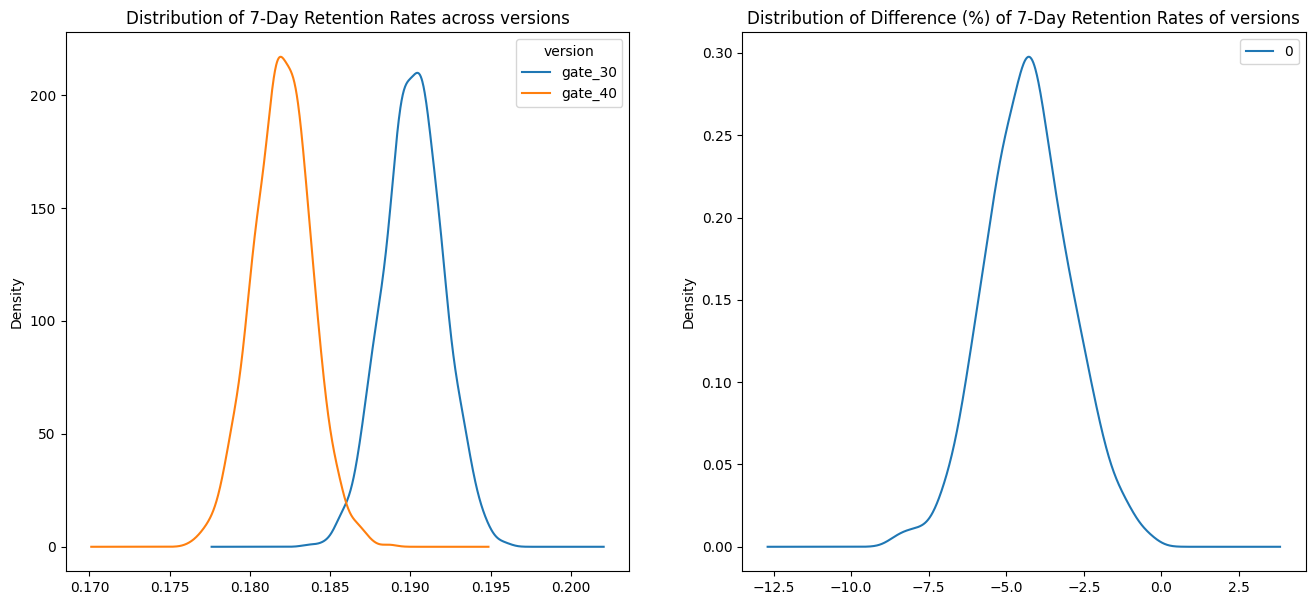

In [32]:
# Do a Bootstrap simulation to see the estimated retention rate distribution
boot_r7 = []
boot_r7_diff = []

for i in range(1000):
    boot = data.sample(frac = 1,replace = True)
    boot_mean = boot.groupby('version')['retention_7'].mean()
    boot_diff = (boot.groupby('version')['retention_7'].mean()[1] - boot.groupby('version')['retention_7'].mean()[0])/(boot.groupby('version')['retention_7'].mean()[0]) * 100

    boot_r7.append(boot_mean)
    boot_r7_diff.append(boot_diff)
# Transforming the list to a DataFrame
boot_r7 = pd.DataFrame(boot_r7)
boot_r7_diff = pd.DataFrame(boot_r7_diff)

# A Kernel Density Estimate plot of the bootstrap distributions
fig_4, axes_4 = plt.subplots(1,2, figsize = (16,7))

boot_r7.plot(kind='density', ax = axes_4[0])
boot_r7_diff.plot(kind = 'density', ax = axes_4[1])
axes_4[0].set_title("Distribution of 7-Day Retention Rates across versions", fontsize = 12)
axes_4[1].set_title("Distribution of Difference (%) of 7-Day Retention Rates of versions", fontsize = 12)

In [33]:
# Print the probability of difference lower than 0
print('Probability that 7-day Retention Rate in Level 40 is lower when the Rate at Level 30:',float(round((boot_r7_diff < 0).mean(),5)))

Probability that 7-day Retention Rate in Level 40 is lower when the Rate at Level 30: 1.0


From the result above, we have the strong evidence that the new version (Gate 40) has a negative impact on the user engagement and resulted in a 4.29% drop compared with the current version (Gate 30).

8. Result interpretation & Launch Decision


From the testing results for the 3 metrices, we can conclude that from statistical perspective, the new version should not be launched to all users since it did not perform a good impact on customer engagement, and even lowered their retention acitivites. Therefore we should not launch the new version to all users.

Even if the test result for the success metric shows that the new version is better than the old version, we need to further think about if the enhancement magnitude is Practically Significant and meet the MDE (Minimum Detectable Effect) threshold. This is important since a 0.1% increase in user engagement could also be statistically signifiacnet, but it makes no sense to the business since the effect size is so low and the benefit of it is highly likely much lower than the cost of implementation. Therefore, we should account for both the business and technical factors before making the final decision on the new version roll-out.

9. Improvement Ideas & Risk Control


This section will discuss the ideas we can enhance the test and some factors we should consider before & during the test in real life.

1) Improvement Ideas:
Given the data used in the project is in its completed version, in real life A/B Testing, there are a few ideas we can think of improving the quality of our test:

1. Metrics Design: choose the optimal success metric and driver metrices is the most important step through the test phase, and the factors for choosing are measurable, sensitive to change, visible in short-term and contributive to long-term profitability.

2. A/A Test: Perform A/A Test regularly is important to ensure we have the most qualified tool and random sampling method. A biased platform could introduce many issues such as Sample Ratio Mismatch (SRM) and inconsistent class assignment, which will introduces selection bias that invalidates any test results. Besides, this test is also a good method to find the estimated sample variance which will be used to determine the minimum sample size.

9. Improvement Ideas & Risk Control
This section will discuss the ideas we can enhance the test and some factors we should consider before & during the test in real life.

1) Improvement Ideas:
Given the data used in the project is in its completed version, in real life A/B Testing, there are a few ideas we can think of improving the quality of our test:

1. Metrics Design: choose the optimal success metric and driver metrices is the most important step through the test phase, and the factors for choosing are measurable, sensitive to change, visible in short-term and contributive to long-term profitability.

2. A/A Test: Perform A/A Test regularly is important to ensure we have the most qualified tool and random sampling method. A biased platform could introduce many issues such as Sample Ratio Mismatch (SRM) and inconsistent class assignment, which will introduces selection bias that invalidates any test results. Besides, this test is also a good method to find the estimated sample variance which will be used to determine the minimum sample size.

3. Power Analysis: Power Analysis is a useful method used to not only determine the required minimum sample size of the test based on the selected parameters and variance, but also measure whether the selected sample size is qualified enough to make the conclusion. We should carefully conduct the analysis before launching the testing steps.

2) Risk Control¶
There are also some risk factors and their solutions for the real life A/B Testing cases:

1. Heavy User Adjustment: for some products, there are only a small group contributing the most profits (20% customers contribute to 80% profit). Therefore, we should have a threshold on the traffic splitting tool to ensure we got a certain percentage of high-value customers in each group. For instance, we found 20% users purchasing the 80% items in our game, then in the testing we need to ensure both groups have roughly 20% these funs to avoid getting bias.

2. Ceteris Paribus: this issue happens when the treatment brings extra variation except for the treatment effect. For instance, the new version has brought extra delay in the loading time of the game after the used logged in. The extra variation could affect the overall user experience and bring down the positive effect, cause the business to lose their opportunity. To fix this, we should ensure that both groups have the same variation during the testing period.

3. Spillover Effect: this issue exists if there are interactions between the two groups and it usually happens in the social media industry (e.g. Facebook, Google, LinkedIn). For social media apps, the people in the control groups are tending to be affected by their friends or families in their social circle who are in the treatment, which could Underestimate the treatment effect. This issue should be solved when identified during the test or preparation phase.

4. Novelty and Primacy Effect: this happens when the existing users could tend to actively try new features or relunctent to change, which brings bias in the short-term period. For instance, the existing users are used to the product itself, get are interested in the new feature and use it in the first a couple of days, but once they lose their interest or find it is not useful, they will not use it and the metrics drop in the following days or weeks. It is a common issue and we can solve it by bringing New Users to our test, who haven't used this product before.